In [4]:
import zipfile

with zipfile.ZipFile("archive (3).zip", "r") as z:
    z.extractall(".")
    print("Files extracted:", z.namelist())

Files extracted: ['Telco_customer_churn.xlsx']


In [6]:
import pandas as pd

df = pd.read_excel("Telco_customer_churn.xlsx")
print("Raw shape:", df.shape)

df.columns = df.columns.str.strip().str.replace(" ", "_")

df['Total_Charges'] = df['Total_Charges'].replace(" ", "0")
df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')
df['Total_Charges'] = df['Total_Charges'].fillna(0)

df['Churn_Reason'] = df['Churn_Reason'].fillna("Still Active")

cols_to_drop = ['Count', 'Lat_Long', 'Latitude', 'Longitude', 'Country', 'State']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("Missing values :", df.isnull().sum().sum())
print("Duplicates     :", df.duplicated().sum())
print("Clean shape    :", df.shape)

df.to_csv("telco_churn_cleaned.csv", index=False)
print("Done!")

Raw shape: (7043, 33)
Missing values : 0
Duplicates     : 0
Clean shape    : (7043, 27)
Done!


In [7]:
from google.colab import files
files.download("telco_churn_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

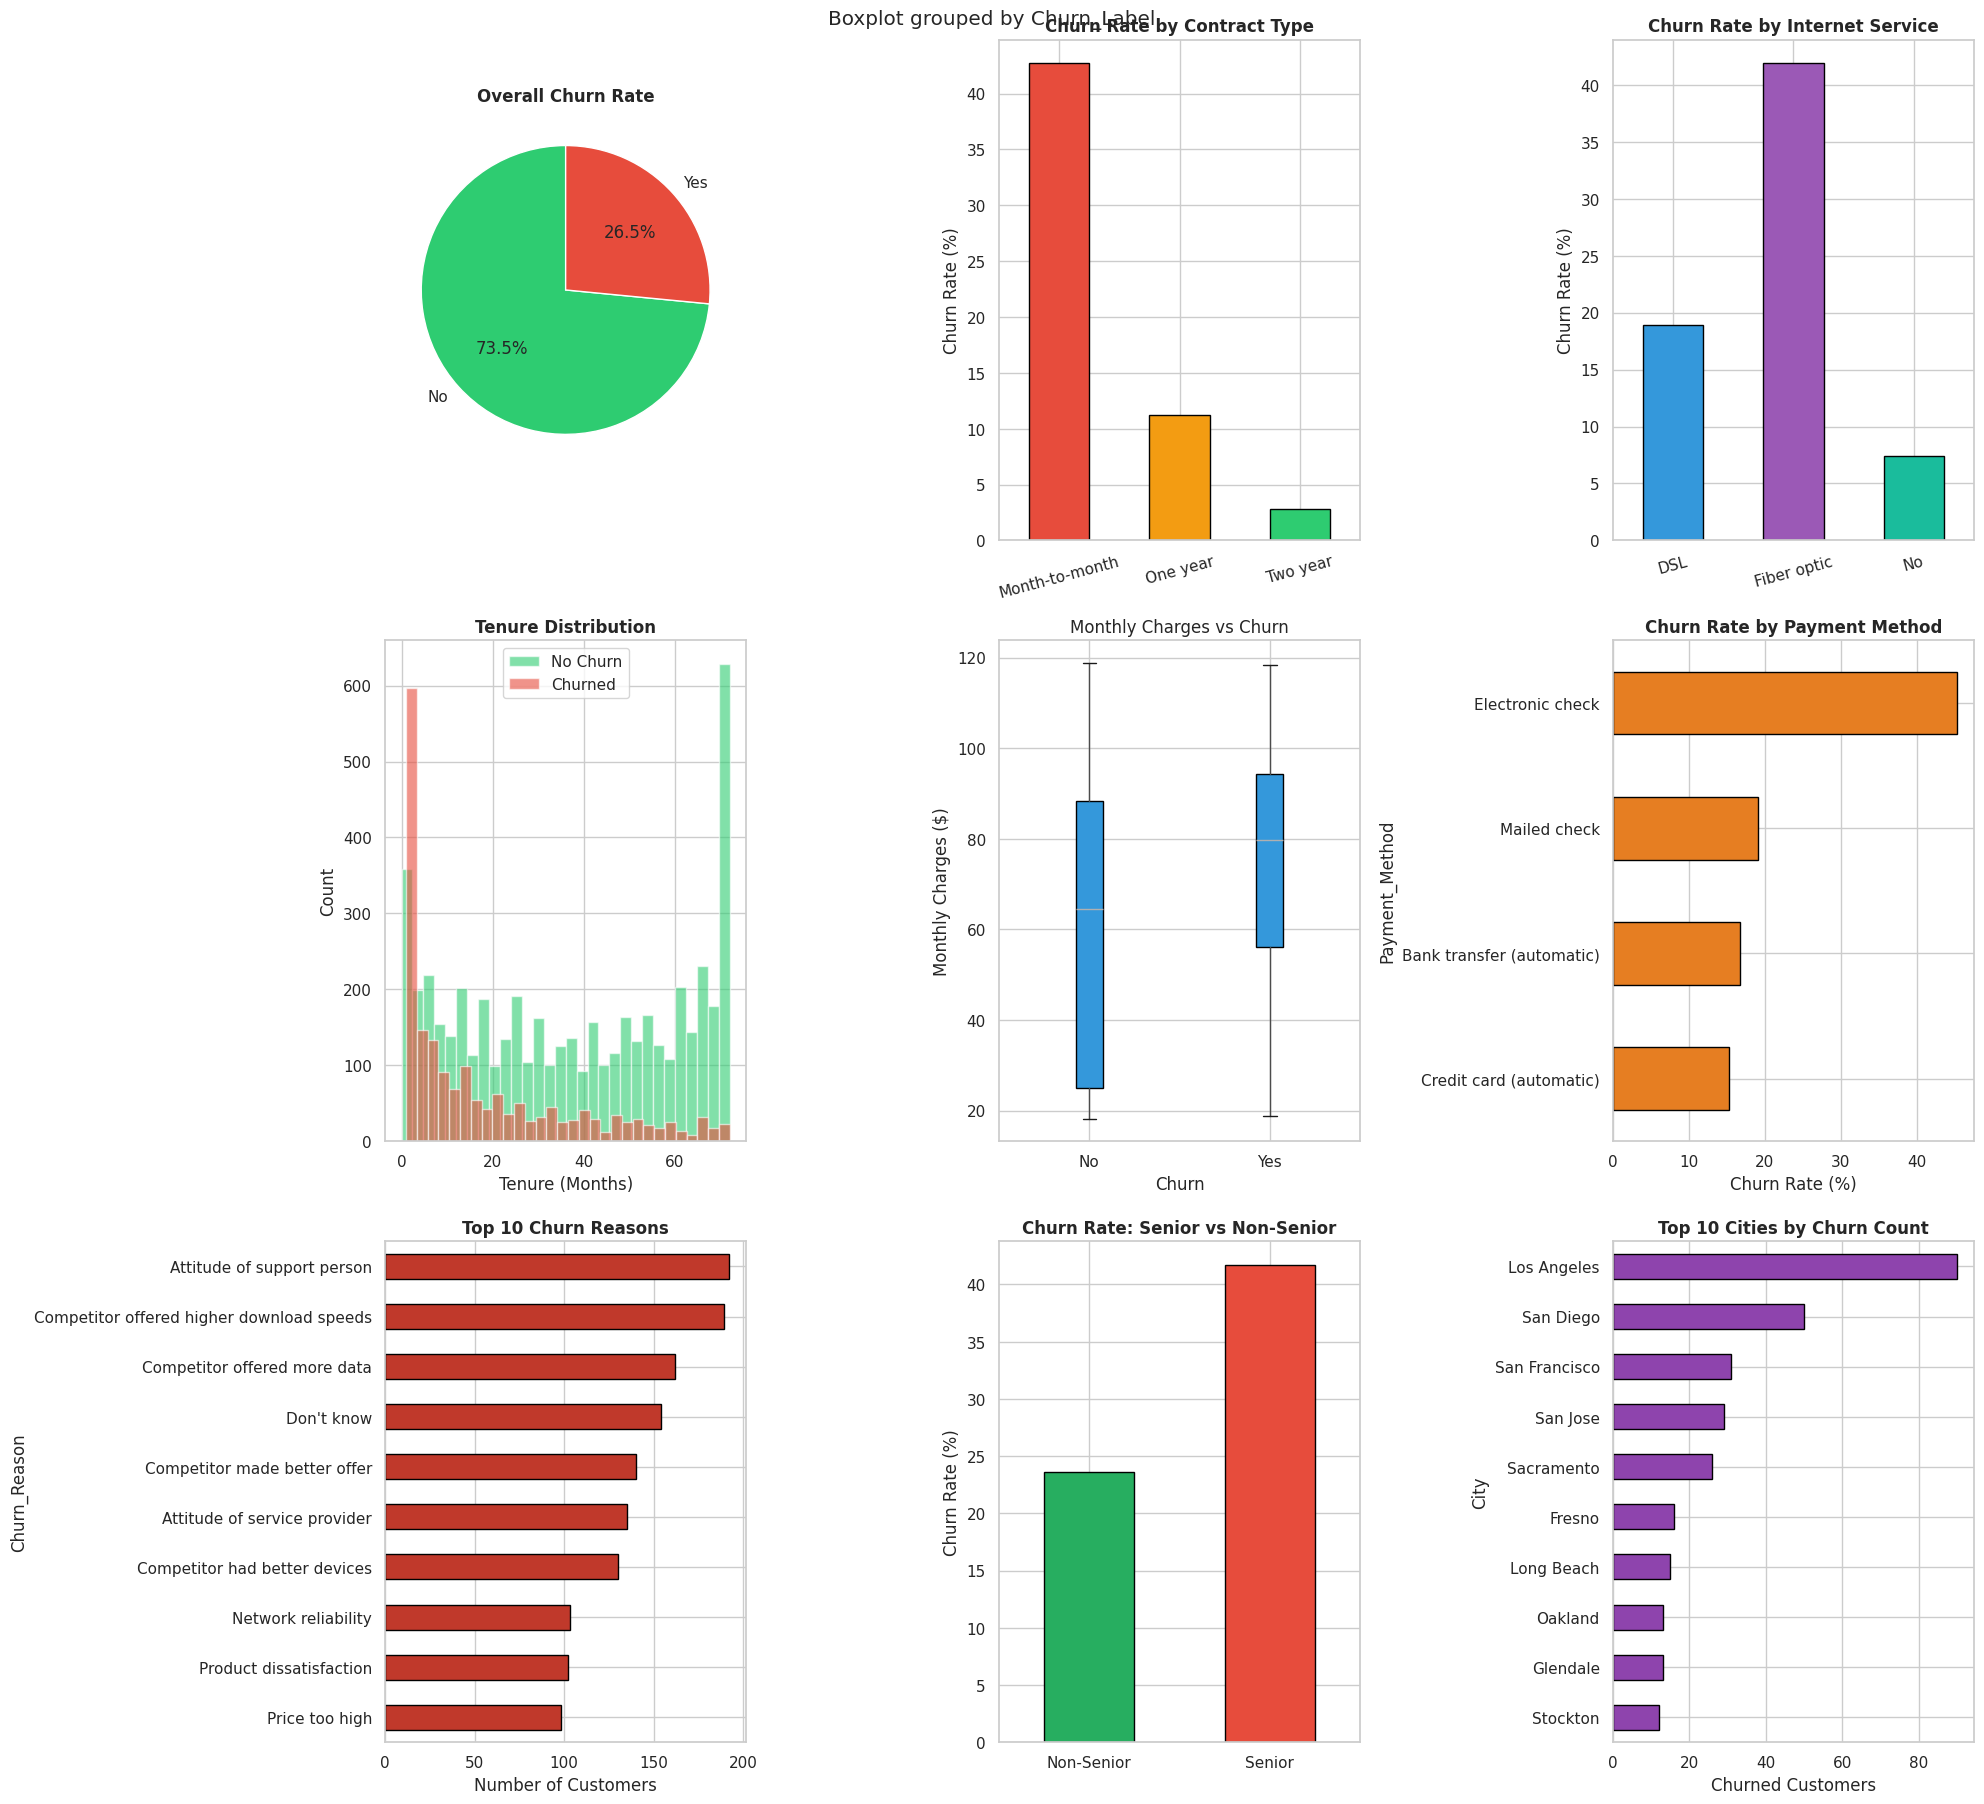

 EDA Complete! Charts saved as eda_charts.png


In [8]:
"""
KARMIX TECH INTERNSHIP
Project : Customer Churn Prediction Dashboard
Step 2  : Exploratory Data Analysis (EDA)
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("telco_churn_cleaned.csv")

sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(20, 24))
fig.suptitle("Customer Churn - Exploratory Data Analysis",
             fontsize=22, fontweight='bold', y=0.98)


ax1 = fig.add_subplot(4, 3, 1)
churn_counts = df['Churn_Label'].value_counts()
ax1.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'], startangle=90)
ax1.set_title("Overall Churn Rate", fontweight='bold')


ax2 = fig.add_subplot(4, 3, 2)
contract_churn = df.groupby('Contract')['Churn_Value'].mean() * 100
contract_churn.plot(kind='bar', ax=ax2, color=['#e74c3c','#f39c12','#2ecc71'],
                    edgecolor='black')
ax2.set_title("Churn Rate by Contract Type", fontweight='bold')
ax2.set_ylabel("Churn Rate (%)")
ax2.set_xlabel("")
ax2.tick_params(axis='x', rotation=15)


ax3 = fig.add_subplot(4, 3, 3)
internet_churn = df.groupby('Internet_Service')['Churn_Value'].mean() * 100
internet_churn.plot(kind='bar', ax=ax3, color=['#3498db','#9b59b6','#1abc9c'],
                    edgecolor='black')
ax3.set_title("Churn Rate by Internet Service", fontweight='bold')
ax3.set_ylabel("Churn Rate (%)")
ax3.set_xlabel("")
ax3.tick_params(axis='x', rotation=15)


ax4 = fig.add_subplot(4, 3, 4)
df[df['Churn_Label']=='No']['Tenure_Months'].hist(ax=ax4, bins=30,
    alpha=0.6, color='#2ecc71', label='No Churn')
df[df['Churn_Label']=='Yes']['Tenure_Months'].hist(ax=ax4, bins=30,
    alpha=0.6, color='#e74c3c', label='Churned')
ax4.set_title("Tenure Distribution", fontweight='bold')
ax4.set_xlabel("Tenure (Months)")
ax4.set_ylabel("Count")
ax4.legend()


ax5 = fig.add_subplot(4, 3, 5)
df.boxplot(column='Monthly_Charges', by='Churn_Label', ax=ax5,
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', color='black'))
ax5.set_title("Monthly Charges vs Churn", fontweight='bold')
ax5.set_xlabel("Churn")
ax5.set_ylabel("Monthly Charges ($)")
plt.sca(ax5)
plt.title("Monthly Charges vs Churn")


ax6 = fig.add_subplot(4, 3, 6)
payment_churn = df.groupby('Payment_Method')['Churn_Value'].mean() * 100
payment_churn.sort_values().plot(kind='barh', ax=ax6, color='#e67e22',
                                  edgecolor='black')
ax6.set_title("Churn Rate by Payment Method", fontweight='bold')
ax6.set_xlabel("Churn Rate (%)")


ax7 = fig.add_subplot(4, 3, 7)
reasons = df[df['Churn_Reason'] != 'Still Active']['Churn_Reason'].value_counts().head(10)
reasons.sort_values().plot(kind='barh', ax=ax7, color='#c0392b', edgecolor='black')
ax7.set_title("Top 10 Churn Reasons", fontweight='bold')
ax7.set_xlabel("Number of Customers")


ax8 = fig.add_subplot(4, 3, 8)
senior_churn = df.groupby('Senior_Citizen')['Churn_Value'].mean() * 100
senior_churn.index = ['Non-Senior', 'Senior']
senior_churn.plot(kind='bar', ax=ax8, color=['#27ae60','#e74c3c'], edgecolor='black')
ax8.set_title("Churn Rate: Senior vs Non-Senior", fontweight='bold')
ax8.set_ylabel("Churn Rate (%)")
ax8.tick_params(axis='x', rotation=0)


ax9 = fig.add_subplot(4, 3, 9)
city_churn = df[df['Churn_Label']=='Yes']['City'].value_counts().head(10)
city_churn.sort_values().plot(kind='barh', ax=ax9, color='#8e44ad', edgecolor='black')
ax9.set_title("Top 10 Cities by Churn Count", fontweight='bold')
ax9.set_xlabel("Churned Customers")

plt.tight_layout()
plt.savefig("eda_charts.png", dpi=150, bbox_inches='tight')
plt.show()
print(" EDA Complete! Charts saved as eda_charts.png")

In [9]:
print(df['Churn_Value'].value_counts())
print(df['Churn_Label'].value_counts())
print(df['Churn_Reason'].value_counts())

Churn_Value
0    5174
1    1869
Name: count, dtype: int64
Churn_Label
No     5174
Yes    1869
Name: count, dtype: int64
Churn_Reason
Still Active                                 5174
Attitude of support person                    192
Competitor offered higher download speeds     189
Competitor offered more data                  162
Don't know                                    154
Competitor made better offer                  140
Attitude of service provider                  135
Competitor had better devices                 130
Network reliability                           103
Product dissatisfaction                       102
Price too high                                 98
Service dissatisfaction                        89
Lack of self-service on Website                88
Extra data charges                             57
Moved                                          53
Limited range of services                      44
Lack of affordable download/upload speed       44
Long distance cha

In [10]:
"""
KARMIX TECH INTERNSHIP
Project : Customer Churn Prediction Dashboard
Step 3  : ML Model - Logistic Regression
"""

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns


df = pd.read_csv("telco_churn_cleaned.csv")


cols = ['Gender', 'Senior_Citizen', 'Partner', 'Dependents',
        'Tenure_Months', 'Phone_Service', 'Multiple_Lines',
        'Internet_Service', 'Online_Security', 'Online_Backup',
        'Device_Protection', 'Tech_Support', 'Streaming_TV',
        'Streaming_Movies', 'Contract', 'Paperless_Billing',
        'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn_Value']

df_ml = df[cols].copy()


le = LabelEncoder()
text_cols = ['Gender', 'Partner', 'Dependents', 'Phone_Service',
             'Multiple_Lines', 'Internet_Service', 'Online_Security',
             'Online_Backup', 'Device_Protection', 'Tech_Support',
             'Streaming_TV', 'Streaming_Movies', 'Contract',
             'Paperless_Billing', 'Payment_Method']

for col in text_cols:
    df_ml[col] = le.fit_transform(df_ml[col])


X = df_ml.drop('Churn_Value', axis=1)
y = df_ml['Churn_Value']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training rows : {X_train.shape[0]}")
print(f"Testing rows  : {X_test.shape[0]}")


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("\n Model trained!")


y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f" Model Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ML Model Results", fontsize=16, fontweight='bold')


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')


importance = pd.Series(
    abs(model.coef_[0]), index=X.columns
).sort_values(ascending=True)

importance.plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig("ml_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("ML Complete! Saved: ml_results.png")

Training rows : 5634
Testing rows  : 1409


ValueError: could not convert string to float: 'No'